# Data Cleaning and Exploratory Data Analysis

#### Sebastián Miramontes Soto

### Data Cleaning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\Sebas\miniconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.4)
  from scipy.stats import gaussian_kde


In [2]:
df = pd.read_csv("../DATASETS/scouting_data/scouting_dataset.csv")
df.head()

,country,league,season,player_name,age,position,nationality,height,weight,appearances,...,fouls_drawn_per90,fouls_committed_per90,yellow_cards_per90,yellowred_cards_per90,red_cards_per90,passes_accuracy_pct,shots_on_target_pct,duels_won_pct,dribbles_success_pct,rating_weighted
0,usa,MLS,2025,AJ Marcucci,26.0,G,USA,191.0,86.0,2,...,0.000000,0.000000,0.000000,0.0,0.0000,18.152542,NaN,NaN,NaN,6.500000
1,turkey,Super Lig,2025,Aaron Appindangoyé,33.0,D,Gabon,185.0,85.0,4,...,0.285714,1.428571,0.000000,0.0,0.0000,29.359712,100.000000,33.333333,NaN,6.285714
2,netherlands,Eredivisie,2025,Aaron Bouwman,18.0,D,Netherlands,188.0,71.0,10,...,0.000000,1.168831,0.233766,0.0,0.0000,67.358657,66.666667,45.652174,100.000000,7.051948
3,usa,MLS,2025 / 2026,Aaron Herrera,28.0,D,Guatemala,180.0,71.0,33,...,0.549004,1.207808,0.402603,0.0,0.0732,32.444118,28.571429,51.327434,46.511628,6.921431
4,england,Premier League,2025,Aaron Hickey,23.0,D,Scotland,178.0,72.0,21,...,1.131285,0.879888,0.125698,0.0,0.0000,21.375439,20.000000,50.000000,0.000000,6.633147


In [3]:
df.shape

(9572, 49)

In [4]:
df = df[(df["position"] != "G") & (df["minutes"] >= 450)].reset_index(drop=True)

In [5]:
df.shape

(5150, 49)

In [6]:
(df.isna().mean() * 100).round(2)

country                              0.00
league                               0.00
season                               0.00
player_name                          0.00
age                                  0.08
position                             0.00
nationality                          0.58
height                               5.96
weight                              10.25
appearances                          0.00
starts                               0.00
minutes                              0.00
goals_total                          0.00
assists                              0.00
penalty_won                          0.00
penalty_committed                    0.00
penalty_scored                       0.00
penalty_missed                       0.00
yellow_cards                         0.00
yellowred_cards                      0.00
red_cards                            0.00
offsides_per90                       0.00
shots_total_per90                    0.00
shots_on_per90                    

In [7]:
df.loc[(df["shots_total_per90"] == 0) & (df["shots_on_target_pct"].isna()), "shots_on_target_pct"] = 0

df.loc[(df["dribbles_attempts_per90"] == 0) & (df["dribbles_success_pct"].isna()), "dribbles_success_pct"] = 0

df = df.drop(columns=["weight"])

df = df.drop(columns=["season"])

df = df.drop(columns=["country"])

df = df.dropna().reset_index(drop=True)

print(df.shape)

(4843, 46)


In [8]:
df["height"].unique()

array([188., 180., 178., 186., 176., 175., 185., 183., 173., 174., 167.,
       184., 190., 177., 182., 195., 168., 189., 181., 170., 172., 191.,
       194., 193., 192., 179., 169., 161., 171., 165., 187., 162., 196.,
       166., 163., 164., 198., 201., 197., 160., 156., 159.])

In [9]:
bins = [154, 162, 170, 178, 186, 194, 202]
labels = ["155-162", "163-170", "171-178", "179-186", "187-194", "195-202"]

df["height"] = pd.cut(df["height"], bins=bins, labels=labels)

In [10]:
df["age"].unique()

array([18., 28., 23., 33., 38., 25., 26., 21., 24., 22., 19., 27., 20.,
       31., 29., 30., 34., 35., 36., 32., 37., 17., 40., 16., 42., 39.,
       41., 44.])

In [11]:
bins = [15, 20, 24, 27, 31, 35, 45]
labels = ["16-20", "21-24", "25-27", "28-31", "32-35", "36-45"]

df["age"] = pd.cut(df["age"], bins=bins, labels=labels)

In [12]:
print("TOPNACIONALITIES")
print(df["nationality"].value_counts().head(10))

print("\nTOP LEAGUES")
print(df["league"].value_counts().head(12))

TOPNACIONALITIES
nationality
Argentina      676
Brazil         534
Spain          330
France         279
Netherlands    242
USA            234
Germany        198
Mexico         186
Portugal       178
England        155
Name: count, dtype: int64

TOP LEAGUES
league
MLS                 587
Primera Division    585
Serie A Brazil      453
La Liga             363
Serie A             361
Premier League      341
Primeira Liga       316
Bundesliga          316
Super Lig           307
Eredivisie          306
Ligue 1             297
Liga MX             282
Name: count, dtype: int64


In [13]:
league_groups = {
    "La Liga": "EUROPE 1", "Premier League": "EUROPE 1", "Serie A": "EUROPE 1", "Ligue 1": "EUROPE 1", "Bundesliga": "EUROPE 1",
    "Primeira Liga": "EUROPE 2", "Super Lig": "EUROPE 2", "Eredivisie": "EUROPE 2",
    "Liga MX": "CONCACAF", "MLS": "CONCACAF",
    "Primera Division": "CONMEBOL", "Serie A Brazil": "CONMEBOL"}

group_order = ["EUROPE 1", "EUROPE 2", "CONCACAF", "CONMEBOL"]

def classify_league(value):
    leagues = [league.strip() for league in value.split("/")]

    if len(leagues) >= 3:
        return "MULTIPLE"

    groups = list(dict.fromkeys(league_groups[league] for league in leagues))

    if len(groups) == 1:
        return groups[0]

    groups = sorted(groups, key=group_order.index)
    return " / ".join(groups)

df["league"] = df["league"].apply(classify_league)

In [14]:
confederations = {
    "CONMEBOL": [
        "Argentina", "Brazil", "Uruguay", "Colombia", "Paraguay",
        "Chile", "Ecuador", "Venezuela", "Peru", "Bolivia"],

    "CONCACAF": [
        "USA", "Mexico", "Canada", "Jamaica", "Honduras", "Costa Rica",
        "Panama", "Suriname", "Haiti", "Curaçao", "Guatemala",
        "El Salvador", "Trinidad and Tobago", "Guadeloupe",
        "Puerto Rico", "Dominican Republic", "Guyana"],

    "UEFA": [
        "Spain", "France", "Netherlands", "Germany", "Portugal", "England",
        "Italy", "Türkiye", "Belgium", "Denmark", "Norway", "Sweden",
        "Switzerland", "Croatia", "Austria", "Poland", "Serbia", "Greece",
        "Scotland", "Czechia", "Ukraine", "Republic of Ireland",
        "Bosnia and Herzegovina", "Albania", "Slovakia", "Georgia",
        "Hungary", "Iceland", "Israel", "Romania", "Slovenia", "Kosovo",
        "Russia", "Wales", "Finland", "Montenegro", "Luxembourg",
        "Bulgaria", "North Macedonia", "Northern Ireland", "Armenia",
        "Azerbaijan", "Faroe Islands", "Lithuania", "Estonia"],

    "CAF": [
        "Senegal", "Morocco", "Côte d'Ivoire", "Ghana", "Nigeria",
        "Cameroon", "Mali", "Algeria", "Angola", "Tunisia", "Congo DR",
        "Gabon", "Guinea", "Gambia", "Guinea-Bissau", "Cape Verde",
        "Burkina Faso", "Egypt", "Mozambique", "Benin", "South Africa",
        "Zimbabwe", "Tanzania", "Togo", "Congo", "Libya", "Sierra Leone",
        "Comoros", "Niger", "Uganda", "Central African Republic",
        "Zambia", "Chad", "Equatorial Guinea"],

    "AFC": [
        "Japan", "Korea Republic", "Australia", "Uzbekistan",
        "Syria", "Iran", "Jordan", "Saudi Arabia", "Iraq"],

    "OFC": ["New Zealand"]}

nationality_to_confederation = {nationality: confederation
    for confederation, nationalities in confederations.items()
    for nationality in nationalities}

df["nationality"] = df["nationality"].map(nationality_to_confederation)
df = df.rename(columns={"nationality": "nationality_group"})

In [15]:
df.head()

,league,player_name,age,position,nationality_group,height,appearances,starts,minutes,goals_total,...,fouls_drawn_per90,fouls_committed_per90,yellow_cards_per90,yellowred_cards_per90,red_cards_per90,passes_accuracy_pct,shots_on_target_pct,duels_won_pct,dribbles_success_pct,rating_weighted
0,EUROPE 2,Aaron Bouwman,16-20,D,UEFA,187-194,10,8,770.0,1.0,...,0.000000,1.168831,0.233766,0.0,0.0000,67.358657,66.666667,45.652174,100.000000,7.051948
1,CONCACAF,Aaron Herrera,28-31,D,CONCACAF,179-186,33,28,2459.0,0.0,...,0.549004,1.207808,0.402603,0.0,0.0732,32.444118,28.571429,51.327434,46.511628,6.921431
2,EUROPE 1,Aaron Hickey,21-24,D,UEFA,171-178,21,8,716.0,0.0,...,1.131285,0.879888,0.125698,0.0,0.0000,21.375439,20.000000,50.000000,0.000000,6.633147
3,CONCACAF,Aaron Long,32-35,D,CONCACAF,179-186,20,20,1627.0,1.0,...,0.221266,0.719115,0.055317,0.0,0.0000,72.006977,50.000000,67.346939,0.000000,7.085618
4,EUROPE 2,Aaron Meijers,36-45,D,UEFA,171-178,12,5,511.0,0.0,...,1.232877,0.880626,0.000000,0.0,0.0000,18.636364,100.000000,51.063830,40.000000,6.511546


In [16]:
df.to_csv("cleaned_dataset.csv", index=False)

### Exploratory Data Analysis

#### Qualitative

In [17]:
cols = ["player_name", "age", "position"]
possible_duplicates = df[df.duplicated(subset=cols, keep=False)].sort_values(cols)
print(len(possible_duplicates))
display(possible_duplicates)

4


,league,player_name,age,position,nationality_group,height,appearances,starts,minutes,goals_total,...,fouls_drawn_per90,fouls_committed_per90,yellow_cards_per90,yellowred_cards_per90,red_cards_per90,passes_accuracy_pct,shots_on_target_pct,duels_won_pct,dribbles_success_pct,rating_weighted
343,CONMEBOL,André Silva,28-31,F,CONMEBOL,179-186,30,19,1765.0,5.0,...,1.427762,1.631728,0.407932,0.0,0.0,9.947531,48.148148,38.048780,17.647059,6.824320
344,EUROPE 1,André Silva,28-31,F,UEFA,179-186,31,22,1859.0,10.0,...,1.646046,1.161915,0.145239,0.0,0.0,16.590631,69.047619,38.325991,41.176471,6.840527
3036,CONCACAF,Marlon,28-31,D,CONMEBOL,179-186,11,7,633.0,0.0,...,0.710900,1.421801,0.000000,0.0,0.0,69.653211,0.000000,54.166667,100.000000,7.055924
3037,CONMEBOL,Marlon,28-31,D,CONMEBOL,171-178,38,37,3389.0,2.0,...,1.407495,1.248156,0.239009,0.0,0.0,33.478202,42.857143,57.014925,57.777778,7.131956


In [18]:
qualitative_columns = ["league", "age", "position", "nationality_group", "height"]

qualitative_lists = {}

for column in qualitative_columns:

    percentages = (df[column].value_counts(normalize=True, dropna=False).mul(100).sort_values(ascending=False))

    qualitative_lists[column] = [f"{category} - {percentage:.2f}%"
        for category, percentage in percentages.items()]

for column, values in qualitative_lists.items():

    print(f"\n{column.upper()}")

    for value in values:
        print(value)


LEAGUE
EUROPE 1 - 36.28%
CONMEBOL - 22.05%
EUROPE 2 - 19.47%
CONCACAF - 18.32%
EUROPE 1 / EUROPE 2 - 1.20%
CONCACAF / CONMEBOL - 1.14%
EUROPE 1 / CONMEBOL - 0.52%
EUROPE 1 / CONCACAF - 0.45%
EUROPE 2 / CONMEBOL - 0.39%
EUROPE 2 / CONCACAF - 0.12%
MULTIPLE - 0.06%

AGE
21-24 - 29.28%
25-27 - 25.13%
28-31 - 24.88%
32-35 - 11.07%
16-20 - 6.92%
36-45 - 2.73%

POSITION
D - 38.01%
M - 37.27%
F - 24.72%

NATIONALITY_GROUP
UEFA - 47.08%
CONMEBOL - 33.16%
CONCACAF - 10.55%
CAF - 7.85%
AFC - 1.28%
OFC - 0.08%

HEIGHT
179-186 - 40.28%
171-178 - 31.39%
187-194 - 20.26%
163-170 - 6.48%
195-202 - 1.40%
155-162 - 0.19%


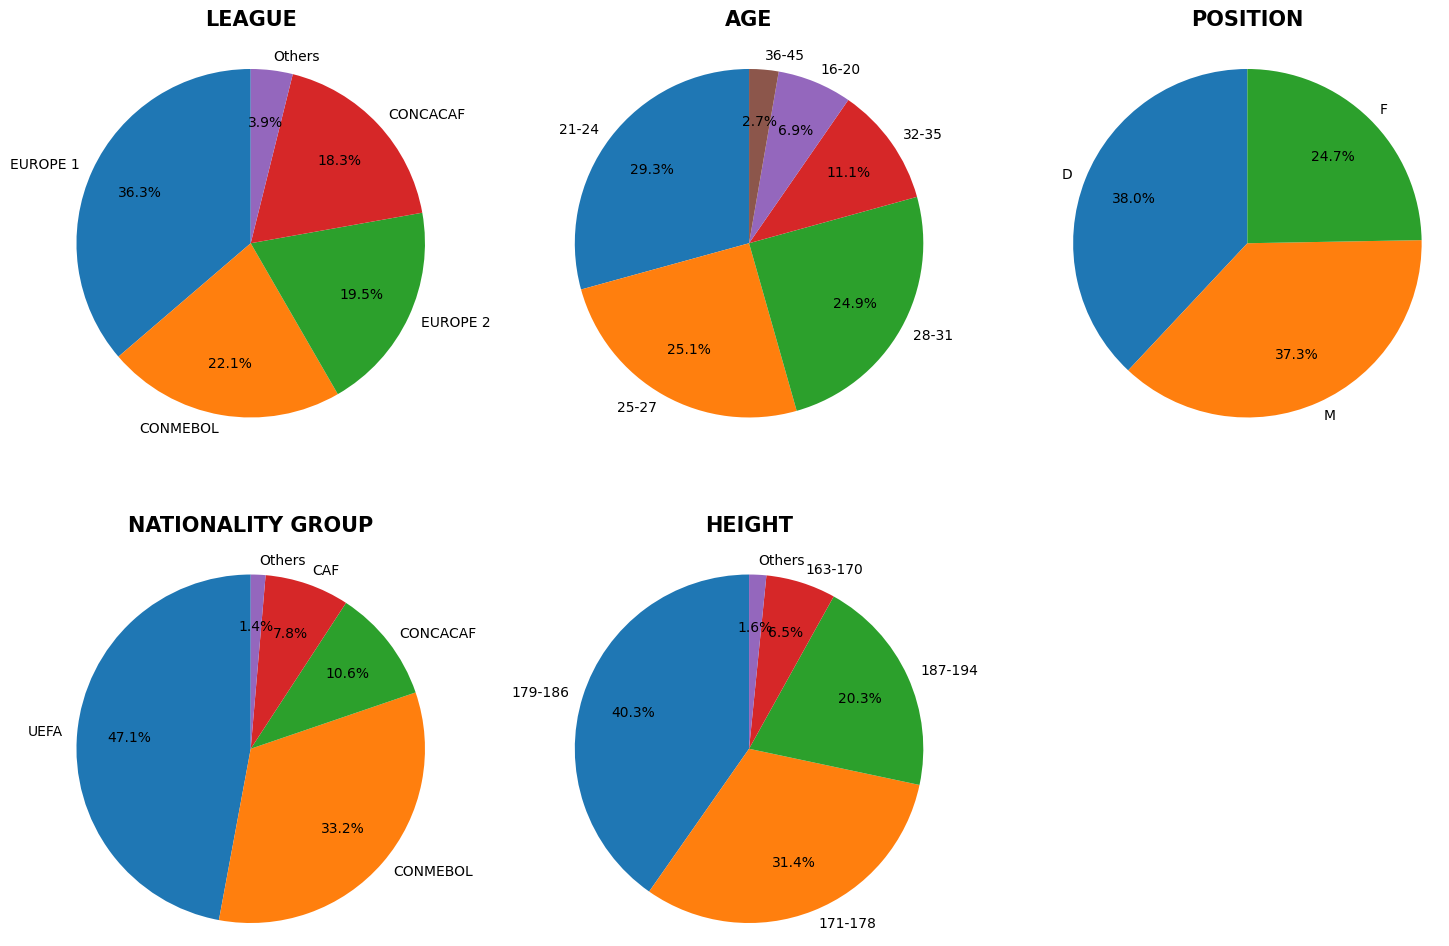

In [19]:
columns = ["league", "age", "position", "nationality_group", "height"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, column in zip(axes, columns):
    counts = df[column].value_counts()

    if len(counts) > 5:
        percentages = counts / counts.sum() * 100
        main_counts = counts[percentages > 2]
        others_count = counts[percentages <= 2].sum()

        if others_count > 0:
            counts = pd.concat([main_counts, pd.Series({"Others": others_count})])

    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        startangle=90, labeldistance=1.08, pctdistance=0.70, textprops={"fontsize": 10})

    ax.set_title(column.replace("_", " ").upper(), fontsize=15, fontweight="bold", pad=22)

    ax.axis("equal")

for ax in axes[len(columns):]:
    ax.axis("off")

plt.subplots_adjust(left=0.04, right=0.96, top=0.93, bottom=0.05, wspace=0.30, hspace=0.35)

plt.show()

#### Quantitative

In [20]:
df.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
appearances,4843.0,26.857113,9.650128,5.000000,20.000000,27.000000,33.000000,57.000000
starts,4843.0,19.589098,10.553128,1.000000,11.000000,18.000000,27.000000,53.000000
minutes,4843.0,1759.941978,891.180225,450.000000,1018.500000,1651.000000,2370.000000,4810.000000
goals_total,4843.0,2.580632,3.813963,0.000000,0.000000,1.000000,3.000000,48.000000
assists,4843.0,1.804047,2.286891,0.000000,0.000000,1.000000,3.000000,30.000000
penalty_won,4843.0,0.215982,0.563975,0.000000,0.000000,0.000000,0.000000,6.000000
penalty_committed,4843.0,0.269668,0.571565,0.000000,0.000000,0.000000,0.000000,5.000000
penalty_scored,4843.0,0.239108,0.859996,0.000000,0.000000,0.000000,0.000000,10.000000
penalty_missed,4843.0,0.066281,0.285880,0.000000,0.000000,0.000000,0.000000,3.000000
yellow_cards,4843.0,4.013008,3.098219,0.000000,2.000000,3.000000,6.000000,19.000000


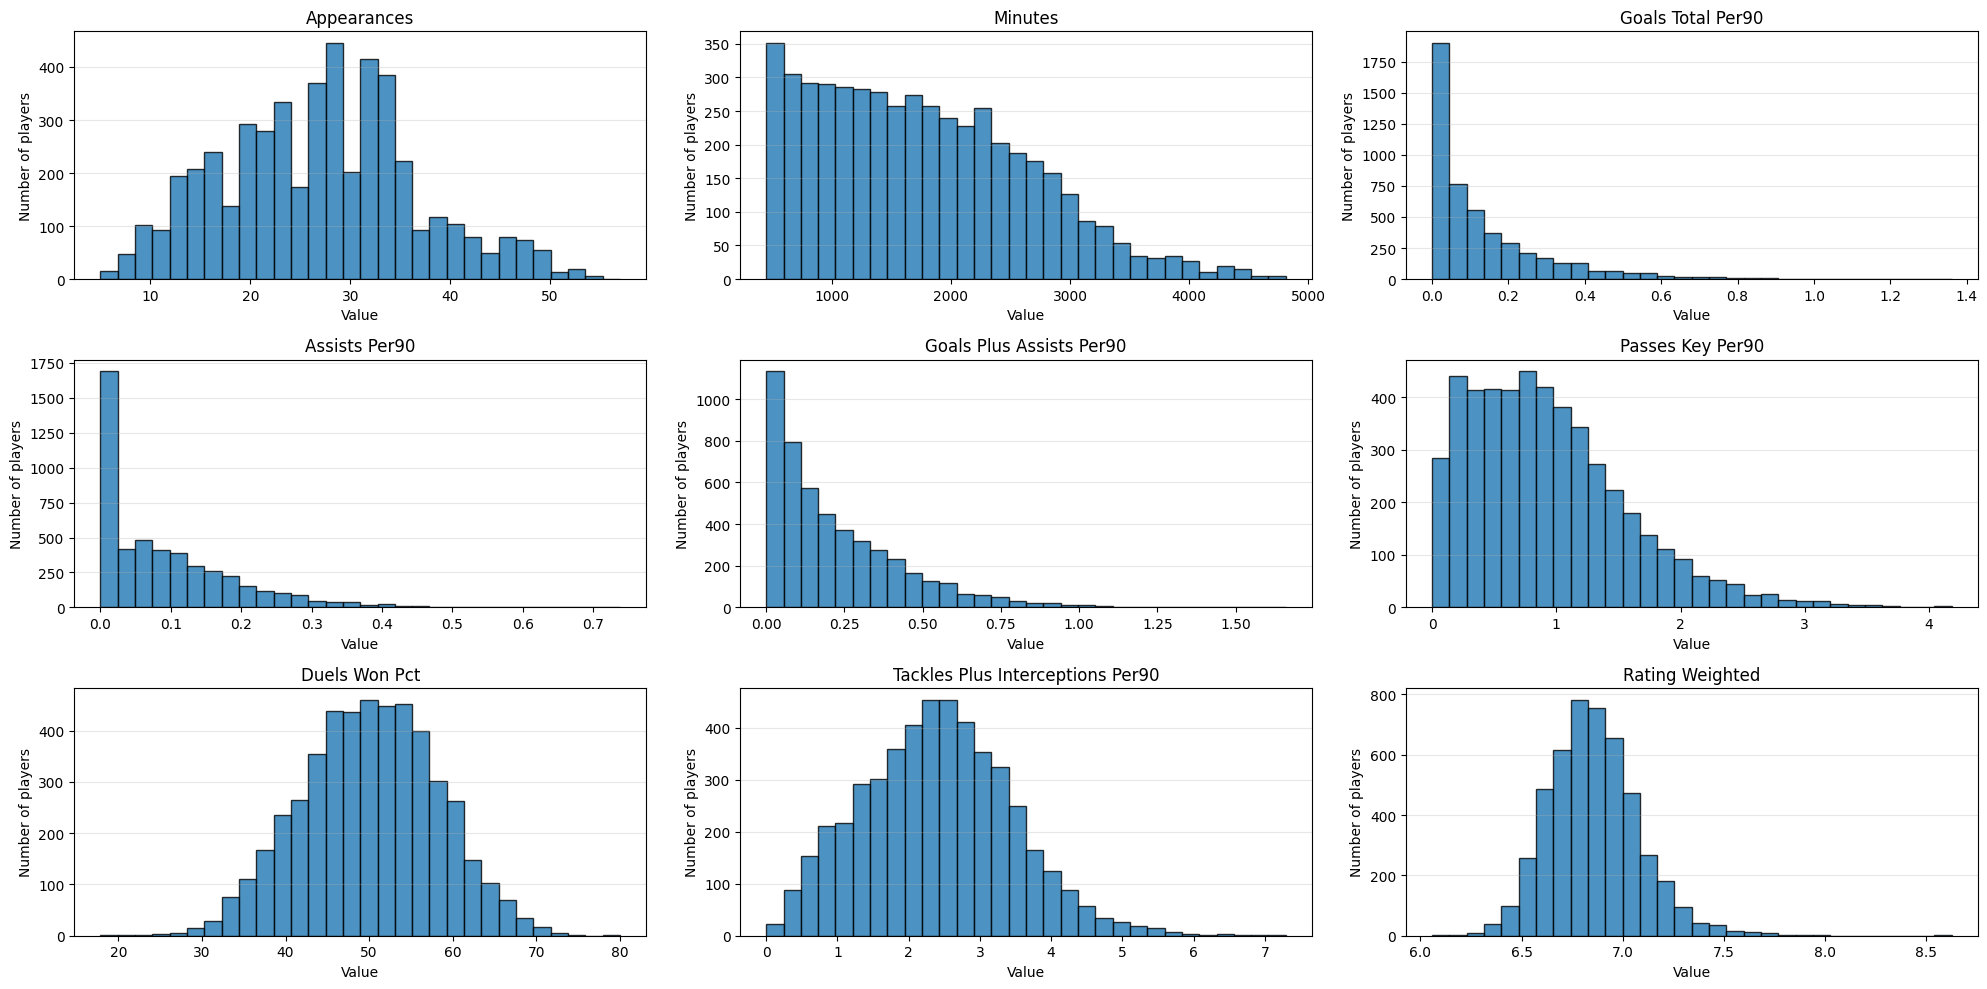

In [21]:
variables = [
    "appearances",
    "minutes",
    "goals_total_per90",
    "assists_per90",
    "goals_plus_assists_per90",
    "passes_key_per90",
    "duels_won_pct",
    "tackles_plus_interceptions_per90",
    "rating_weighted"]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 10))

axes = axes.flatten()

for ax, variable in zip(axes, variables):

    datos = df[variable].dropna()

    ax.hist(datos, bins=30, edgecolor="black", alpha=0.8)

    ax.set_title(variable.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Number of players")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
for category in variables:
    print(f"\n{category}:")

    top_players = df.nlargest(10, category)

    for _, player in top_players.iterrows():
        print(f"- {player['player_name']} - {player[category]:.2f}")


appearances:
- Pedro Vite - 57.00
- Agustin Ojeda - 54.00
- Anders Dreyer - 54.00
- Justin Haak - 54.00
- Onni Valakari - 54.00
- Álvaro Angulo - 54.00
- Alan Lescano - 53.00
- Christian Rivera - 53.00
- Maxi Moralez - 53.00
- Nicolas Oroz - 53.00

minutes:
- João Victor - 4810.00
- Anders Dreyer - 4795.00
- Willian Machado - 4683.00
- Justin Haak - 4673.00
- Francisco Álvarez - 4633.00
- Fabio Pereyra - 4605.00
- Alan Lescano - 4574.00
- Fabrício Bruno - 4540.00
- Marlon Freitas - 4521.00
- Cristian Paz - 4503.00

goals_total_per90:
- Harry Kane - 1.36
- Bertuğ Yıldırım - 1.14
- Lionel Messi - 1.02
- Kento Shiogai - 1.02
- Ricardo Pepi - 1.00
- Daniel Bragança - 1.00
- Orri Steinn Óskarsson - 0.96
- Mauro Icardi - 0.94
- Luis Javier Suárez - 0.93
- Ansu Fati - 0.91

assists_per90:
- Michael Olise - 0.74
- Daniele Verde - 0.73
- Lassi Lappalainen - 0.73
- Pizzi - 0.69
- Jack Skahan - 0.66
- Fábio Silva - 0.65
- Alexis Vega - 0.65
- Lionel Messi - 0.64
- Bruno Fernandes - 0.62
- Bilal 